# Load Data

In [2]:
from utils import *
import numpy as np
import matplotlib.pyplot as plt

data_dir = "physionet.org/files/nsr2db/1.0.0"
rr_data = load_rr_intervals(data_dir)

  nsr001: 106464 beats, mean HR = 79.0 bpm
  nsr002: 111334 beats, mean HR = 79.5 bpm
  nsr003: 97585 beats, mean HR = 69.3 bpm
  nsr004: 97821 beats, mean HR = 70.5 bpm
  nsr005: 116773 beats, mean HR = 81.7 bpm
  nsr006: 102662 beats, mean HR = 74.3 bpm
  nsr007: 106792 beats, mean HR = 76.1 bpm
  nsr008: 107739 beats, mean HR = 75.4 bpm
  nsr009: 102861 beats, mean HR = 71.8 bpm
  nsr010: 96252 beats, mean HR = 70.1 bpm
  nsr011: 115900 beats, mean HR = 81.5 bpm
  nsr012: 98905 beats, mean HR = 69.1 bpm
  nsr013: 115757 beats, mean HR = 82.3 bpm
  nsr014: 111896 beats, mean HR = 78.2 bpm
  nsr015: 100961 beats, mean HR = 75.9 bpm
  nsr016: 94767 beats, mean HR = 77.2 bpm
  nsr017: 100959 beats, mean HR = 70.4 bpm
  nsr018: 107982 beats, mean HR = 77.3 bpm
  nsr019: 122822 beats, mean HR = 85.7 bpm
  nsr020: 136481 beats, mean HR = 97.7 bpm
  nsr021: 103875 beats, mean HR = 72.5 bpm
  nsr022: 81720 beats, mean HR = 57.8 bpm
  nsr023: 112094 beats, mean HR = 78.2 bpm
  nsr024: 101102 

# Step 1: build the cumulative time series B(i) from the detrended and normalised heart beat time series b(i)

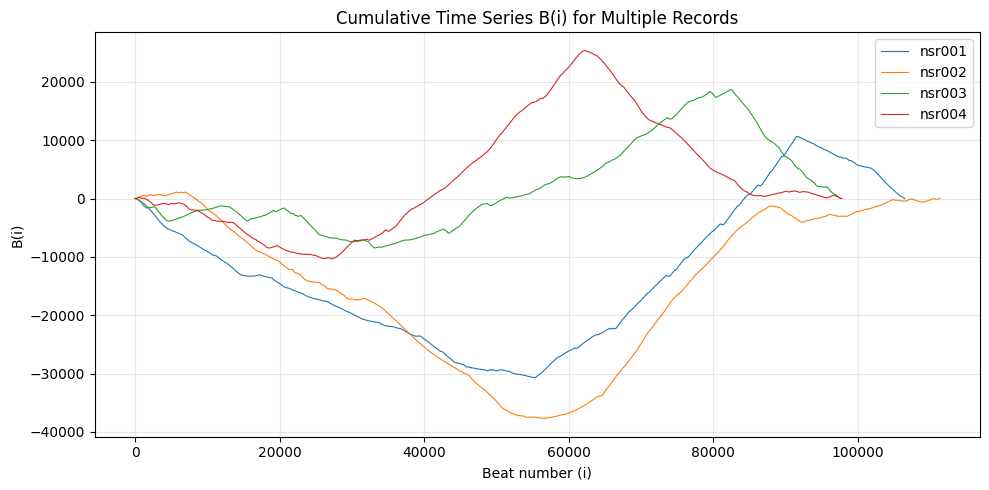

In [6]:
# Dictionaries to store the normalized b(i) and cumulative B(i) time series
b_data = {}
B_data = {}

for record_name, rr in rr_data.items():
    # 1. Calculate mean (\mu) and standard deviation (\sigma)
    mu = np.mean(rr)
    sigma = np.std(rr)
    
    # 2. Normalize the RR intervals to get b(i)
    b_i = (rr - mu) / sigma
    b_data[record_name] = b_i
    
    # 3. Integrate (cumulative sum) to get B(i)
    B_i = np.cumsum(b_i)
    B_data[record_name] = B_i

first_n = 4 # Plot the first_n random walks
records_to_plot = list(B_data.keys())[:first_n]

plt.figure(figsize=(10, 5))

for record_name in records_to_plot:
    plt.plot(B_data[record_name], lw=0.8, label=f"{record_name}")

plt.title("Cumulative Time Series B(i) for Multiple Records")
plt.xlabel("Beat number (i)")
plt.ylabel("B(i)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 2 & 3: Polynomial Detrending and Calculating Increments

The paper describes a specific sliding-window technique (related to Detrended Fluctuation Analysis, DFA):
1. Take a sliding window of size $2s$.
2. Fit a polynomial (the paper uses 3rd order) to the data in that window.
3. Subtract the polynomial trend to get the residual fluctuations, $B^*(i)$.
4. Calculate the increment across scale $s$ within that window: $\Delta_s B = B^*(s) - B^*(0)$.
5. Slide the window forward by 1 beat and repeat.

Calculating detrended increments for nsr001 at scale s=64...


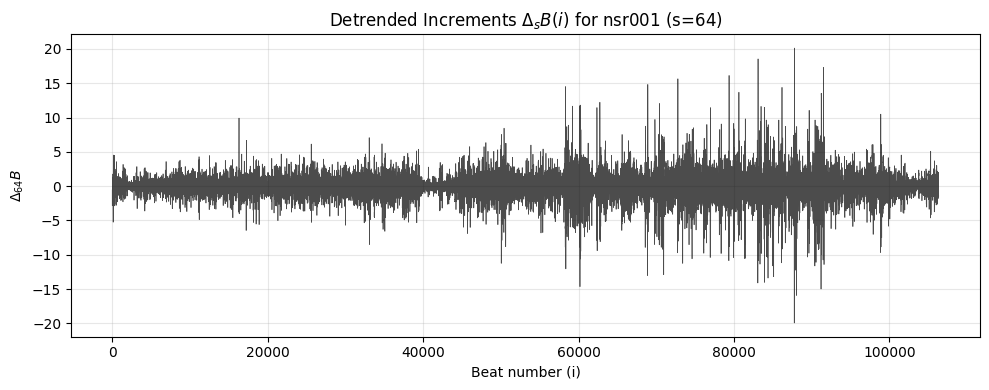

In [ ]:
def get_detrended_increments(B_array: np.ndarray, s: int, order: int=3):
    """
    Extracts detrended increments \\Delta_s B(i) using a sliding window.
    
    B_array: Cumulative time series array
    s: time scale (number of beats)
    order: polynomial order for detrending (paper uses 3rd order)
    """
    N = len(B_array)
    window_size = 2 * s
    increments = []
    
    # x-axis for our local window
    x = np.arange(window_size)
    
    # We slide the window one beat at a time
    for i in range(N - window_size + 1):
        # 1. Grab the local segment of size 2s
        window_data = B_array[i : i + window_size]
        
        # 2. Fit an 'order'-th degree polynomial
        coeffs = np.polyfit(x, window_data, order)
        poly_trend = np.polyval(coeffs, x)
        
        # 3. Calculate deviation from the polynomial fit (B*)
        B_star = window_data - poly_trend
        
        # 4. Calculate the increment at scale s 
        # (In local coordinates, from index 0 to index s)
        delta_B = B_star[s] - B_star[0]
        
        increments.append(delta_B)
        
    return np.array(increments)

# Let's test it on a single record at a single scale (e.g., s = 64 beats)
s_test = 64
test_record = list(B_data.keys())[0]
B_test = B_data[test_record]

print(f"Calculating detrended increments for {test_record} at scale s={s_test}...")
delta_B_s64 = get_detrended_increments(B_test, s=s_test, order=3)

# Plot the resulting increments
plt.figure(figsize=(10, 4))
plt.plot(delta_B_s64, lw=0.5, color='black', alpha=0.7)
plt.title(rf"Detrended Increments $\Delta_s B(i)$ for {test_record} (s={s_test})")
plt.xlabel("Beat number (i)")
plt.ylabel(rf"$\Delta_{{{s_test}}} B$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()